IMPORT

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

BASE_DIR = Path("..")

PROCESSED_DIR = BASE_DIR / "data" / "processed"
TABLES_DIR = BASE_DIR / "outputs" / "tables"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


LOAD DATASETS

In [2]:
rfm = pd.read_csv(
    PROCESSED_DIR / "rfm_clustered.csv"
)

behaviour = pd.read_csv(
    PROCESSED_DIR / "rfm_refined_behavioural_clustered.csv"
)

print(rfm.shape)
print(behaviour.shape)

(4338, 7)
(4338, 12)


PREPROCESSING 

In [3]:


from sklearn.preprocessing import RobustScaler

rfm_features = [
    "Recency",
    "Frequency",
    "Monetary"
]

behaviour_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Customer_Lifetime_Days",
    "Purchase_Velocity",
    "Purchase_Interval_Std",
    "Purchase_Regularity_Index",
    "Invoice_Value_CV"
]


def cap_outliers_iqr(data):
    capped = data.copy()

    for col in capped.columns:
        q1 = capped[col].quantile(0.25)
        q3 = capped[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        capped[col] = capped[col].clip(lower=lower, upper=upper)

    return capped


def preprocess_features(data):
    processed = cap_outliers_iqr(data)

    log_columns = [
        "Frequency",
        "Monetary",
        "Customer_Lifetime_Days",
        "Purchase_Velocity",
        "Purchase_Interval_Std"
    ]

    for col in log_columns:
        if col in processed.columns:
            processed[col] = np.log1p(processed[col])

    scaler = RobustScaler()
    scaled = scaler.fit_transform(processed)

    return scaled


rfm_data = rfm[rfm_features]
behaviour_data = behaviour[behaviour_features]

rfm_scaled = preprocess_features(rfm_data)
behaviour_scaled = preprocess_features(behaviour_data)

print("Preprocessing completed.")
print("RFM scaled:", rfm_scaled.shape)
print("Behavioural scaled:", behaviour_scaled.shape)

Preprocessing completed.
RFM scaled: (4338, 3)
Behavioural scaled: (4338, 8)


BASELINE FULL DATA VALIDATION 

In [4]:
# ==========================================================
# FULL DATA K-MEANS VALIDATION
# ==========================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_VALUE = 4

kmeans_rfm = KMeans(
    n_clusters=K_VALUE,
    random_state=42,
    n_init=10
)

rfm_labels = kmeans_rfm.fit_predict(rfm_scaled)

kmeans_behaviour = KMeans(
    n_clusters=K_VALUE,
    random_state=42,
    n_init=10
)

behaviour_labels = kmeans_behaviour.fit_predict(behaviour_scaled)

rfm_full_silhouette = silhouette_score(rfm_scaled, rfm_labels)
behaviour_full_silhouette = silhouette_score(behaviour_scaled, behaviour_labels)

print("Full Data Validation")
print("--------------------")
print("RFM K-Means Silhouette:", round(rfm_full_silhouette, 4))
print("Refined Behavioural K-Means Silhouette:", round(behaviour_full_silhouette, 4))

Full Data Validation
--------------------
RFM K-Means Silhouette: 0.385
Refined Behavioural K-Means Silhouette: 0.4367


BOOTSTRAP STABILITY FUNCTION 

In [5]:
# ==========================================================
# BOOTSTRAP STABILITY FUNCTION
# ==========================================================

def bootstrap_kmeans_silhouette(
    X,
    n_bootstraps=50,
    sample_fraction=0.80,
    k=4,
    random_state=42
):
    np.random.seed(random_state)

    scores = []

    n_samples = X.shape[0]
    sample_size = int(n_samples * sample_fraction)

    for i in range(n_bootstraps):
        sample_indices = np.random.choice(
            np.arange(n_samples),
            size=sample_size,
            replace=True
        )

        X_sample = X[sample_indices]

        model = KMeans(
            n_clusters=k,
            random_state=random_state + i,
            n_init=10
        )

        labels = model.fit_predict(X_sample)

        score = silhouette_score(X_sample, labels)

        scores.append(score)

    return np.array(scores)

RUN BOOTSTRAP VALIDATION

In [6]:
# ==========================================================
# RUN BOOTSTRAP VALIDATION
# ==========================================================

N_BOOTSTRAPS = 50
SAMPLE_FRACTION = 0.80

rfm_bootstrap_scores = bootstrap_kmeans_silhouette(
    rfm_scaled,
    n_bootstraps=N_BOOTSTRAPS,
    sample_fraction=SAMPLE_FRACTION,
    k=K_VALUE,
    random_state=42
)

behaviour_bootstrap_scores = bootstrap_kmeans_silhouette(
    behaviour_scaled,
    n_bootstraps=N_BOOTSTRAPS,
    sample_fraction=SAMPLE_FRACTION,
    k=K_VALUE,
    random_state=42
)

print("Bootstrap validation completed.")
print("RFM bootstrap runs:", len(rfm_bootstrap_scores))
print("Behavioural bootstrap runs:", len(behaviour_bootstrap_scores))

Bootstrap validation completed.
RFM bootstrap runs: 50
Behavioural bootstrap runs: 50


BOOTSTRAP SUMMARY STATS

In [7]:
# ==========================================================
# BOOTSTRAP SUMMARY STATISTICS
# ==========================================================

def bootstrap_summary(scores, model_name):
    return {
        "Model": model_name,
        "Mean Silhouette": round(np.mean(scores), 4),
        "Std Dev": round(np.std(scores), 4),
        "Min": round(np.min(scores), 4),
        "Max": round(np.max(scores), 4),
        "95% CI Lower": round(np.percentile(scores, 2.5), 4),
        "95% CI Upper": round(np.percentile(scores, 97.5), 4)
    }


bootstrap_summary_df = pd.DataFrame([
    bootstrap_summary(rfm_bootstrap_scores, "Traditional RFM K-Means"),
    bootstrap_summary(behaviour_bootstrap_scores, "Refined Behavioural K-Means")
])

display(bootstrap_summary_df)

bootstrap_summary_df.to_csv(
    TABLES_DIR / "bootstrap_stability_summary.csv",
    index=False
)

,Model,Mean Silhouette,Std Dev,Min,Max,95% CI Lower,95% CI Upper
0,Traditional RFM K-Means,0.3861,0.0046,0.3755,0.3995,0.3782,0.3968
1,Refined Behavioural K-Means,0.4363,0.0049,0.4243,0.4443,0.4250,0.4431


BOOTSSTRAP DISTRIBUTION PLOT 

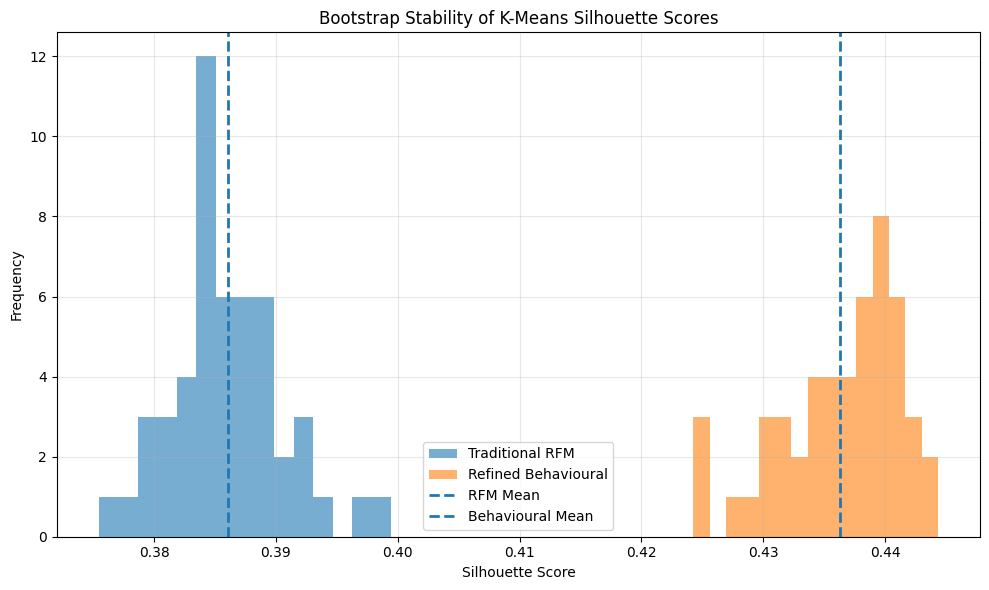

In [8]:
# ==========================================================
# BOOTSTRAP SILHOUETTE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    rfm_bootstrap_scores,
    bins=15,
    alpha=0.6,
    label="Traditional RFM"
)

plt.hist(
    behaviour_bootstrap_scores,
    bins=15,
    alpha=0.6,
    label="Refined Behavioural"
)

plt.axvline(
    np.mean(rfm_bootstrap_scores),
    linestyle="--",
    linewidth=2,
    label="RFM Mean"
)

plt.axvline(
    np.mean(behaviour_bootstrap_scores),
    linestyle="--",
    linewidth=2,
    label="Behavioural Mean"
)

plt.title("Bootstrap Stability of K-Means Silhouette Scores")
plt.xlabel("Silhouette Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "bootstrap_silhouette_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

BOOSTSTRAP SCORE COMPARISON TABLE 

In [9]:
# ==========================================================
# BOOTSTRAP SCORE COMPARISON TABLE
# ==========================================================

bootstrap_scores_df = pd.DataFrame({
    "Bootstrap_Run": range(1, N_BOOTSTRAPS + 1),
    "Traditional_RFM": rfm_bootstrap_scores,
    "Refined_Behavioural": behaviour_bootstrap_scores
})

bootstrap_scores_df["Difference"] = (
    bootstrap_scores_df["Refined_Behavioural"] -
    bootstrap_scores_df["Traditional_RFM"]
)

display(bootstrap_scores_df.head())

bootstrap_scores_df.to_csv(
    TABLES_DIR / "bootstrap_silhouette_scores.csv",
    index=False
)

print("Average Difference:",
      round(bootstrap_scores_df["Difference"].mean(), 4))

,Bootstrap_Run,Traditional_RFM,Refined_Behavioural,Difference
0,1,0.384487,0.429826,0.045339
1,2,0.382478,0.431216,0.048738
2,3,0.382464,0.429216,0.046752
3,4,0.384834,0.442124,0.057291
4,5,0.379604,0.435092,0.055487


Average Difference: 0.0502


STATISTICAL IMPROVEMENT TEST 

In [ ]:
# ==========================================================
# STATISTICAL IMPROVEMENT TEST
# ==========================================================

positive_improvement_rate = (
    bootstrap_scores_df["Difference"] > 0
).mean() * 100

mean_difference = bootstrap_scores_df["Difference"].mean()

ci_lower = np.percentile(
    bootstrap_scores_df["Difference"],
    2.5
)

ci_upper = np.percentile(
    bootstrap_scores_df["Difference"],
    97.5
)

print("="*80)
print("BOOTSTRAP IMPROVEMENT TEST")
print("="*80)

print("Mean Difference:",
      round(mean_difference, 4))
percentage_improvement = (
    mean_difference /
    np.mean(rfm_bootstrap_scores)
) * 100

print(
    "Percentage Improvement:",
    round(percentage_improvement, 2),
    "%"
)

print("95% Confidence Interval:",
      round(ci_lower, 4),
      "to",
      round(ci_upper, 4))

print("Percentage of bootstrap runs where behavioural model outperformed RFM:",
      round(positive_improvement_rate, 2),
      "%")

print("="*80)

BOOTSTRAP IMPROVEMENT TEST
Mean Difference: 0.0502
Percentage Improvement: 13.01 %
95% Confidence Interval: 0.0402 to 0.0585
Percentage of bootstrap runs where behavioural model outperformed RFM: 100.0 %


: 

CLUSTER STABILITY BY SIZE 

In [11]:
# ==========================================================
# CLUSTER SIZE STABILITY
# ==========================================================

def bootstrap_cluster_sizes(
    X,
    n_bootstraps=50,
    sample_fraction=0.80,
    k=4,
    random_state=42
):
    np.random.seed(random_state)

    n_samples = X.shape[0]
    sample_size = int(n_samples * sample_fraction)

    size_records = []

    for i in range(n_bootstraps):
        sample_indices = np.random.choice(
            np.arange(n_samples),
            size=sample_size,
            replace=True
        )

        X_sample = X[sample_indices]

        model = KMeans(
            n_clusters=k,
            random_state=random_state + i,
            n_init=10
        )

        labels = model.fit_predict(X_sample)

        counts = pd.Series(labels).value_counts().sort_index()

        record = {
            "Bootstrap_Run": i + 1
        }

        for cluster in range(k):
            record[f"Cluster_{cluster}_Size"] = counts.get(cluster, 0)

        size_records.append(record)

    return pd.DataFrame(size_records)


behaviour_cluster_size_stability = bootstrap_cluster_sizes(
    behaviour_scaled,
    n_bootstraps=N_BOOTSTRAPS,
    sample_fraction=SAMPLE_FRACTION,
    k=K_VALUE,
    random_state=42
)

display(behaviour_cluster_size_stability.head())

behaviour_cluster_size_stability.to_csv(
    TABLES_DIR / "behavioural_cluster_size_stability.csv",
    index=False
)

,Bootstrap_Run,Cluster_0_Size,Cluster_1_Size,Cluster_2_Size,Cluster_3_Size
0,1,658,1534,613,665
1,2,1551,609,680,630
2,3,643,688,621,1518
3,4,1526,687,653,604
4,5,695,1506,648,621


CLUSTER STABILITY SIZE SUMMARY 

In [12]:
# ==========================================================
# CLUSTER SIZE STABILITY SUMMARY
# ==========================================================

cluster_size_summary = behaviour_cluster_size_stability.drop(
    columns=["Bootstrap_Run"]
).agg(["mean", "std", "min", "max"]).T

cluster_size_summary = cluster_size_summary.round(2)

display(cluster_size_summary)

cluster_size_summary.to_csv(
    TABLES_DIR / "cluster_size_stability_summary.csv"
)

,mean,std,min,max
Cluster_0_Size,998.64,455.41,569.0,1581.0
Cluster_1_Size,1008.74,448.17,560.0,1605.0
Cluster_2_Size,712.34,254.60,578.0,1632.0
Cluster_3_Size,750.28,304.34,576.0,1598.0


CLUSTER STABILITY SIZE PLOT 

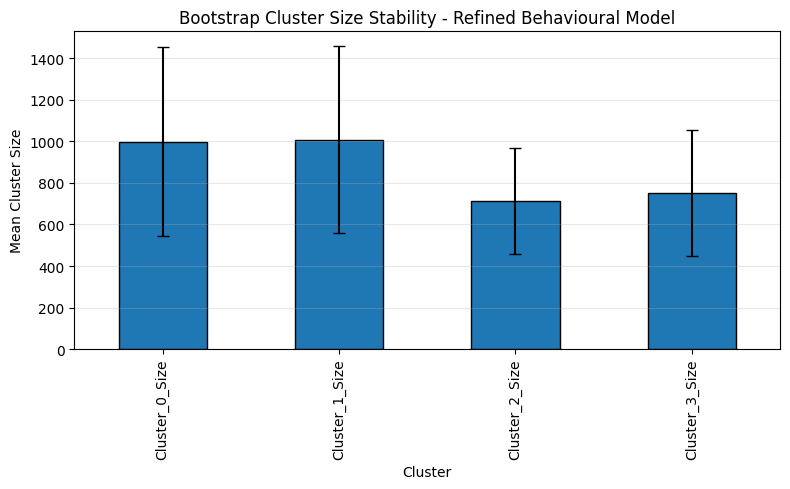

In [13]:
# ==========================================================
# CLUSTER SIZE STABILITY PLOT
# ==========================================================

cluster_size_summary["mean"].plot(
    kind="bar",
    yerr=cluster_size_summary["std"],
    figsize=(8, 5),
    edgecolor="black",
    capsize=4
)

plt.title("Bootstrap Cluster Size Stability - Refined Behavioural Model")
plt.xlabel("Cluster")
plt.ylabel("Mean Cluster Size")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "cluster_size_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FINAL VALIDATION CONCLUSION 

In [14]:
# ==========================================================
# FINAL MODEL VALIDATION CONCLUSION
# ==========================================================

rfm_mean = np.mean(rfm_bootstrap_scores)
behaviour_mean = np.mean(behaviour_bootstrap_scores)

mean_improvement = (
    (behaviour_mean - rfm_mean) / rfm_mean
) * 100

validation_summary_text = f"""
MODEL VALIDATION SUMMARY

Bootstrap validation was performed using {N_BOOTSTRAPS} resamples,
with {int(SAMPLE_FRACTION * 100)}% of customers sampled in each run.

Traditional RFM Mean Silhouette:
{rfm_mean:.4f}

Refined Behavioural Mean Silhouette:
{behaviour_mean:.4f}

Mean Improvement:
{mean_improvement:.2f}%

The refined behavioural volatility model demonstrated stronger average
cluster separation across bootstrap samples. This supports the conclusion
that carefully selected behavioural volatility features provide a stable
improvement over traditional RFM-based segmentation.
"""

print(validation_summary_text)

with open(TABLES_DIR / "model_validation_summary.txt", "w") as f:
    f.write(validation_summary_text)


MODEL VALIDATION SUMMARY

Bootstrap validation was performed using 50 resamples,
with 80% of customers sampled in each run.

Traditional RFM Mean Silhouette:
0.3861

Refined Behavioural Mean Silhouette:
0.4363

Mean Improvement:
13.01%

The refined behavioural volatility model demonstrated stronger average
cluster separation across bootstrap samples. This supports the conclusion
that carefully selected behavioural volatility features provide a stable
improvement over traditional RFM-based segmentation.



EXPLANATION 

In [15]:
# ==========================================================
# FINAL OUTPUT CHECKLIST
# ==========================================================

print("="*80)
print("10_model_validation.ipynb COMPLETED SUCCESSFULLY")
print("="*80)

print("Tables saved:")
print("✓ bootstrap_stability_summary.csv")
print("✓ bootstrap_silhouette_scores.csv")
print("✓ behavioural_cluster_size_stability.csv")
print("✓ cluster_size_stability_summary.csv")
print("✓ model_validation_summary.txt")

print("\nFigures saved:")
print("✓ bootstrap_silhouette_distribution.png")
print("✓ cluster_size_stability.png")

print("="*80)

10_model_validation.ipynb COMPLETED SUCCESSFULLY
Tables saved:
✓ bootstrap_stability_summary.csv
✓ bootstrap_silhouette_scores.csv
✓ behavioural_cluster_size_stability.csv
✓ cluster_size_stability_summary.csv
✓ model_validation_summary.txt

Figures saved:
✓ bootstrap_silhouette_distribution.png
✓ cluster_size_stability.png
